In [11]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score
import plotly.express as px
import nbformat

In [12]:
data = pd.read_csv(r"C:\Users\dell\Downloads\CC GENERAL.csv")

In [13]:
df = data.copy()
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [14]:
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

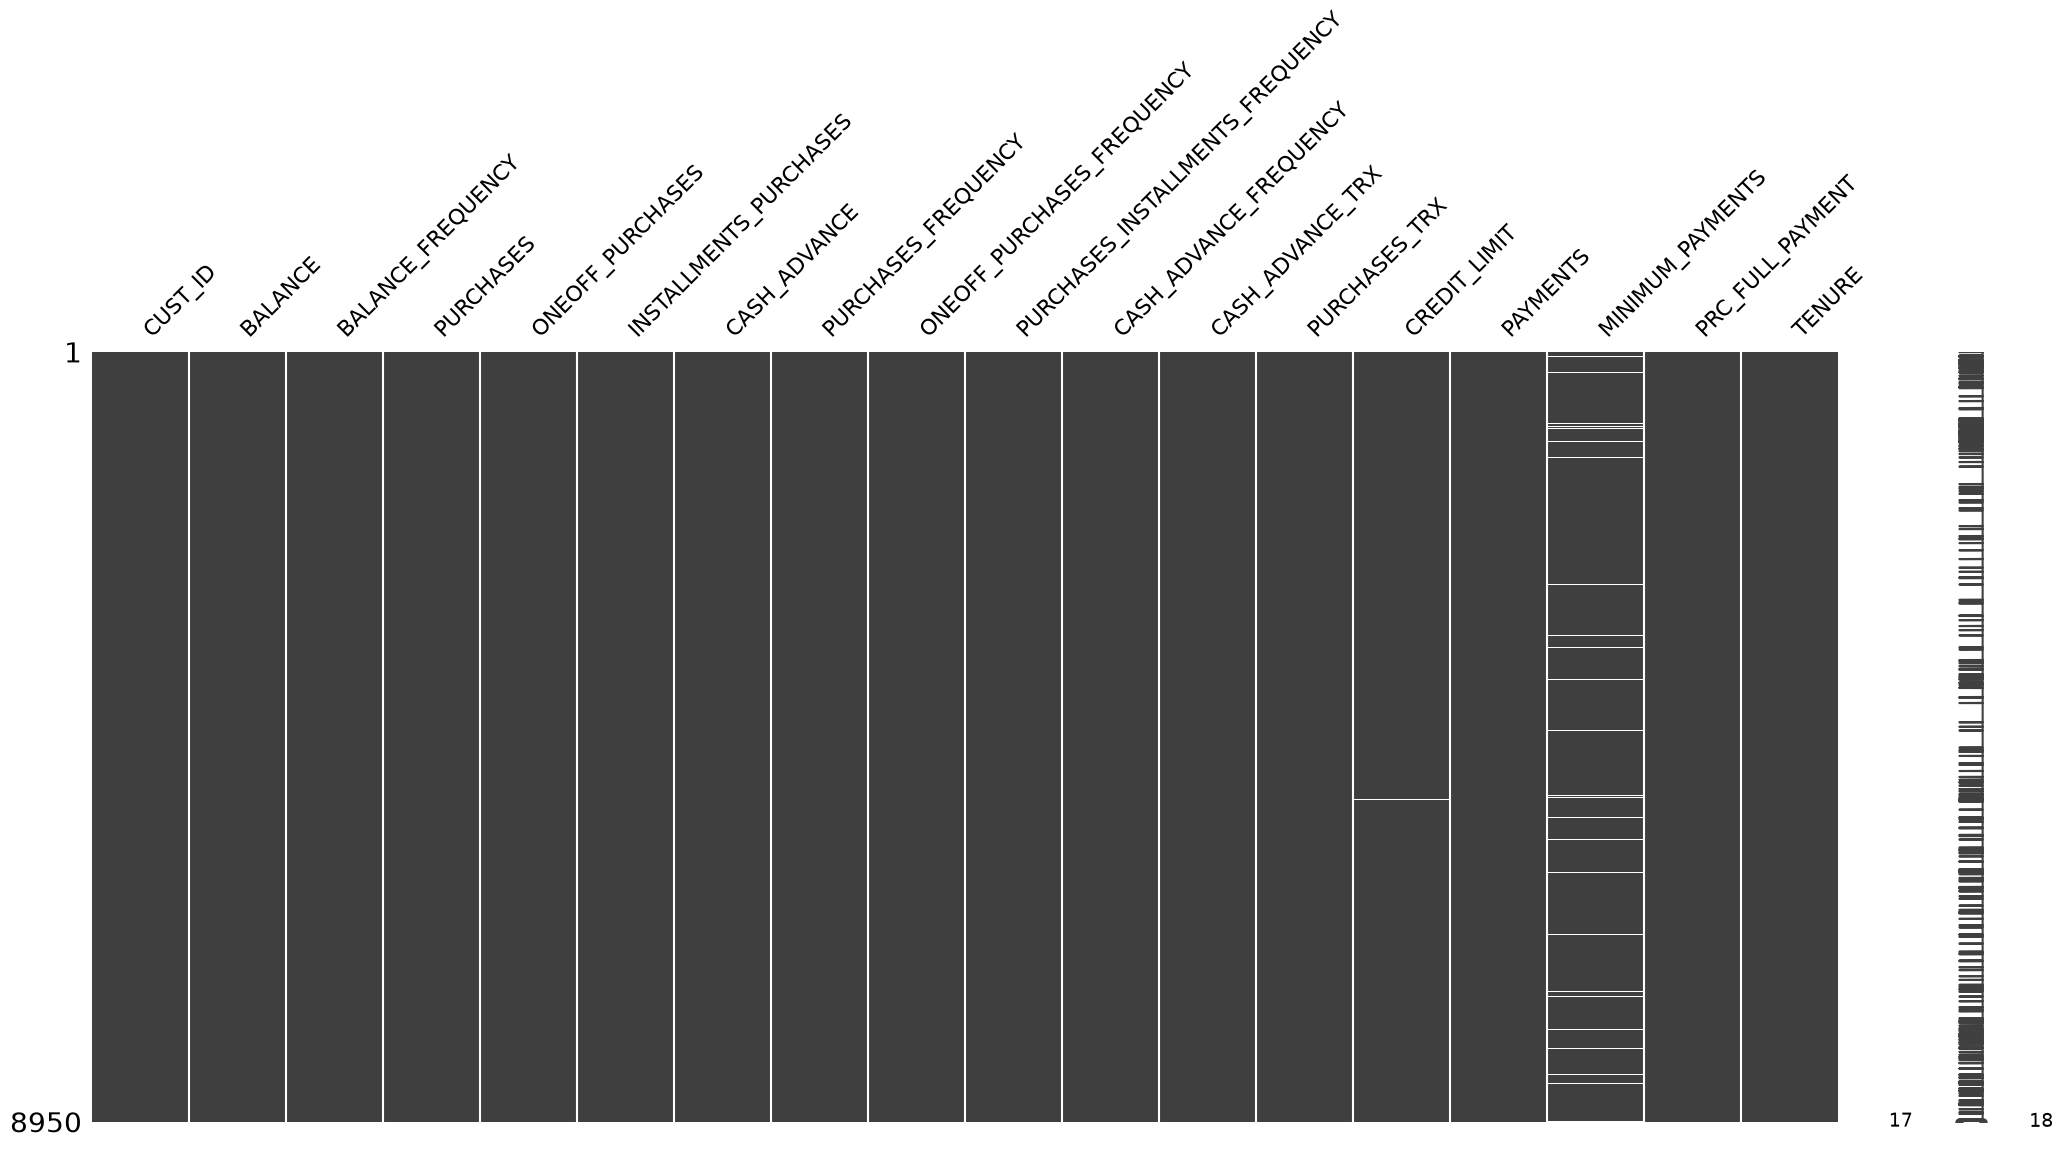

In [15]:
msno.matrix(df)
plt.show()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


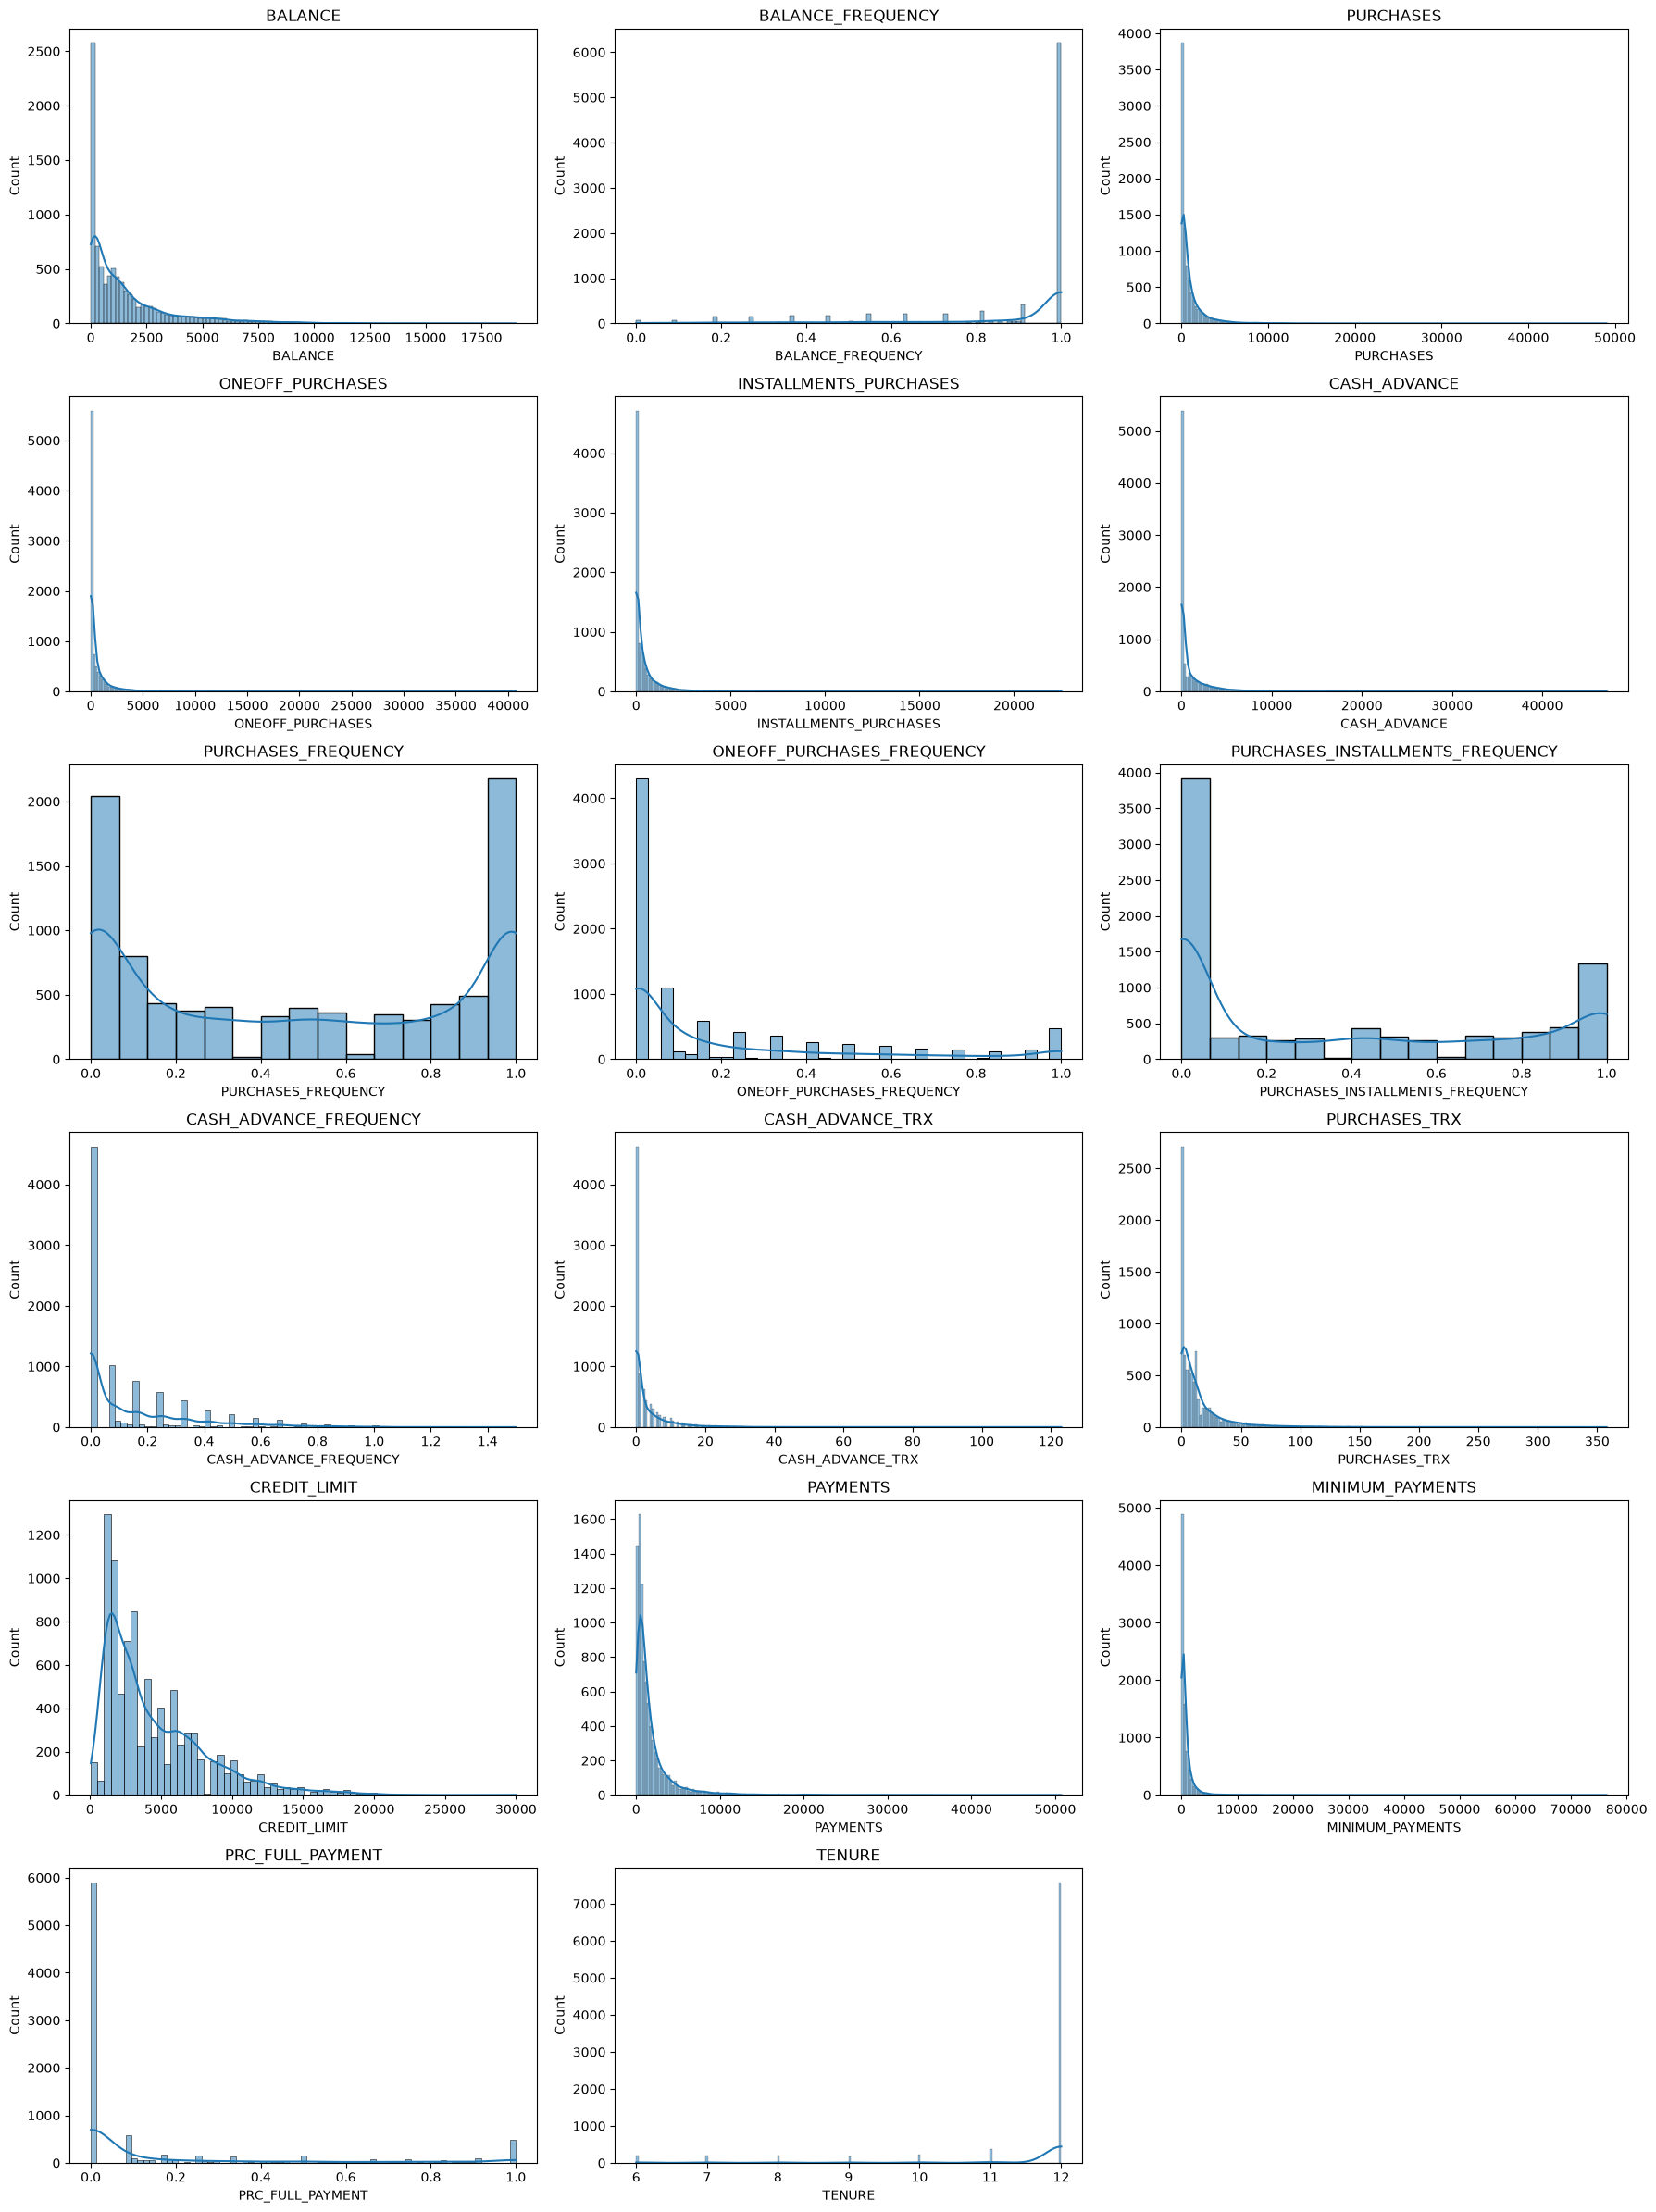

In [28]:
numeric_cols = df.select_dtypes(include='number').columns
n_cols = 3
n_rows = math.ceil(len(numeric_cols)/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize = (18, 4*n_rows))
axes = axes.flatten()
for i,col in enumerate(numeric_cols):
    sns.histplot(data = df, x = col, ax = axes[i], kde = True)
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [29]:
df['TENURE'].value_counts()

TENURE
12    7584
11     365
10     236
6      204
8      196
7      190
9      175
Name: count, dtype: int64

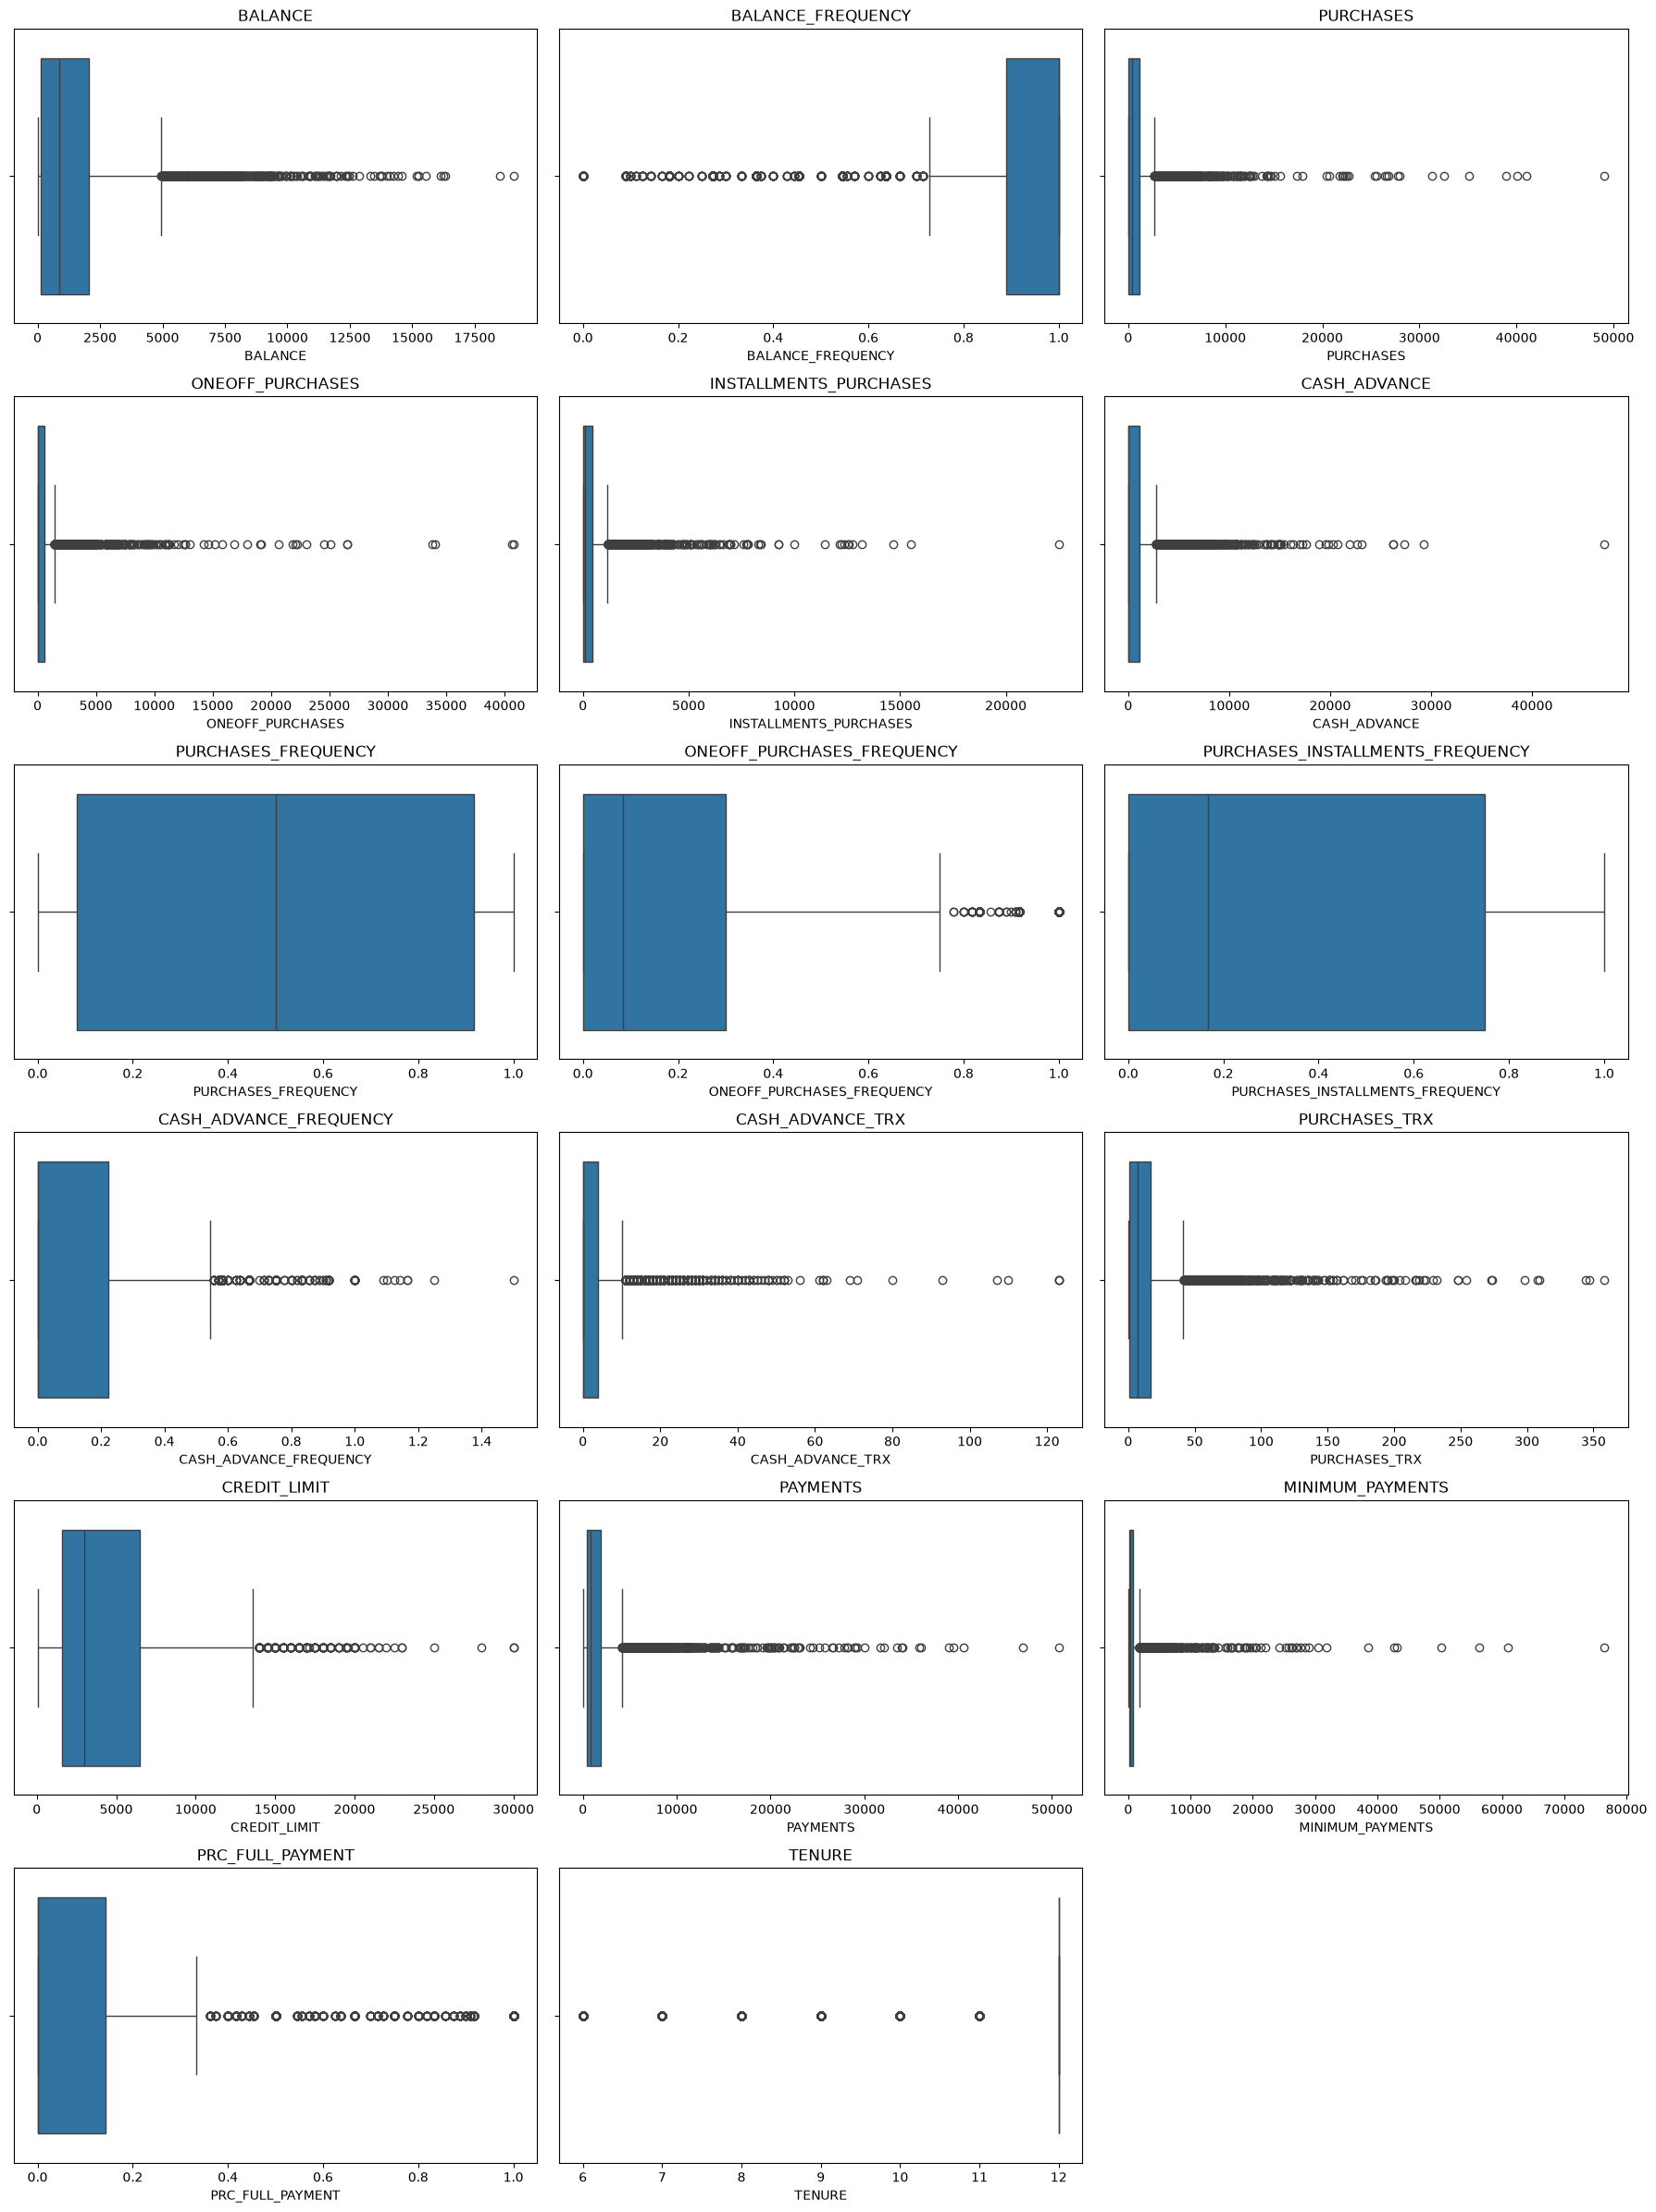

In [30]:
# boxplot visualization
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [32]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Numeric columns par fit and transform karein
df_imputed = df.copy()
numeric_cols = df_imputed.select_dtypes(include='number').columns

df_imputed[numeric_cols] = imputer.fit_transform(df_imputed[numeric_cols])

In [34]:
df_imputed.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


In [35]:
# 1. Imputed data ki copy banayein
df_log = df_imputed.copy()

# 2. Columns list define karein
log_cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CASH_ADVANCE_TRX", "PURCHASES_TRX", "CREDIT_LIMIT",
    "PAYMENTS", "MINIMUM_PAYMENTS"
]

# 3. Ek line mein seedha transform karein
df_log[log_cols] = np.log1p(df_log[log_cols])

In [36]:
df_log

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,3.735304,0.818182,4.568506,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,12.0
1,C10002,8.071989,0.909091,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.250000,1.609438,0.000000,8.853808,8.319725,6.978531,0.222222,12.0
2,C10003,7.822504,1.000000,6.651791,6.651791,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,12.0
3,C10004,7.419183,0.636364,7.313220,7.313220,0.000000,5.331694,0.083333,0.083333,0.000000,0.083333,0.693147,0.693147,8.922792,0.000000,5.747301,0.000000,12.0
4,C10005,6.707735,1.000000,2.833213,2.833213,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,3.384170,1.000000,5.677165,0.000000,5.677165,0.000000,1.000000,0.000000,0.833333,0.000000,0.000000,1.945910,6.908755,5.788719,3.909748,0.500000,6.0
8946,C19187,3.004851,1.000000,5.707110,0.000000,5.707110,0.000000,1.000000,0.000000,0.833333,0.000000,0.000000,1.945910,6.908755,5.623517,5.747301,0.000000,6.0
8947,C19188,3.194529,0.833333,4.979489,0.000000,4.979489,0.000000,0.833333,0.000000,0.666667,0.000000,0.000000,1.791759,6.908755,4.410016,4.423869,0.250000,6.0
8948,C19189,2.671218,0.833333,0.000000,0.000000,0.000000,3.625907,0.000000,0.000000,0.000000,0.166667,1.098612,0.000000,6.216606,3.980615,4.038755,0.250000,6.0


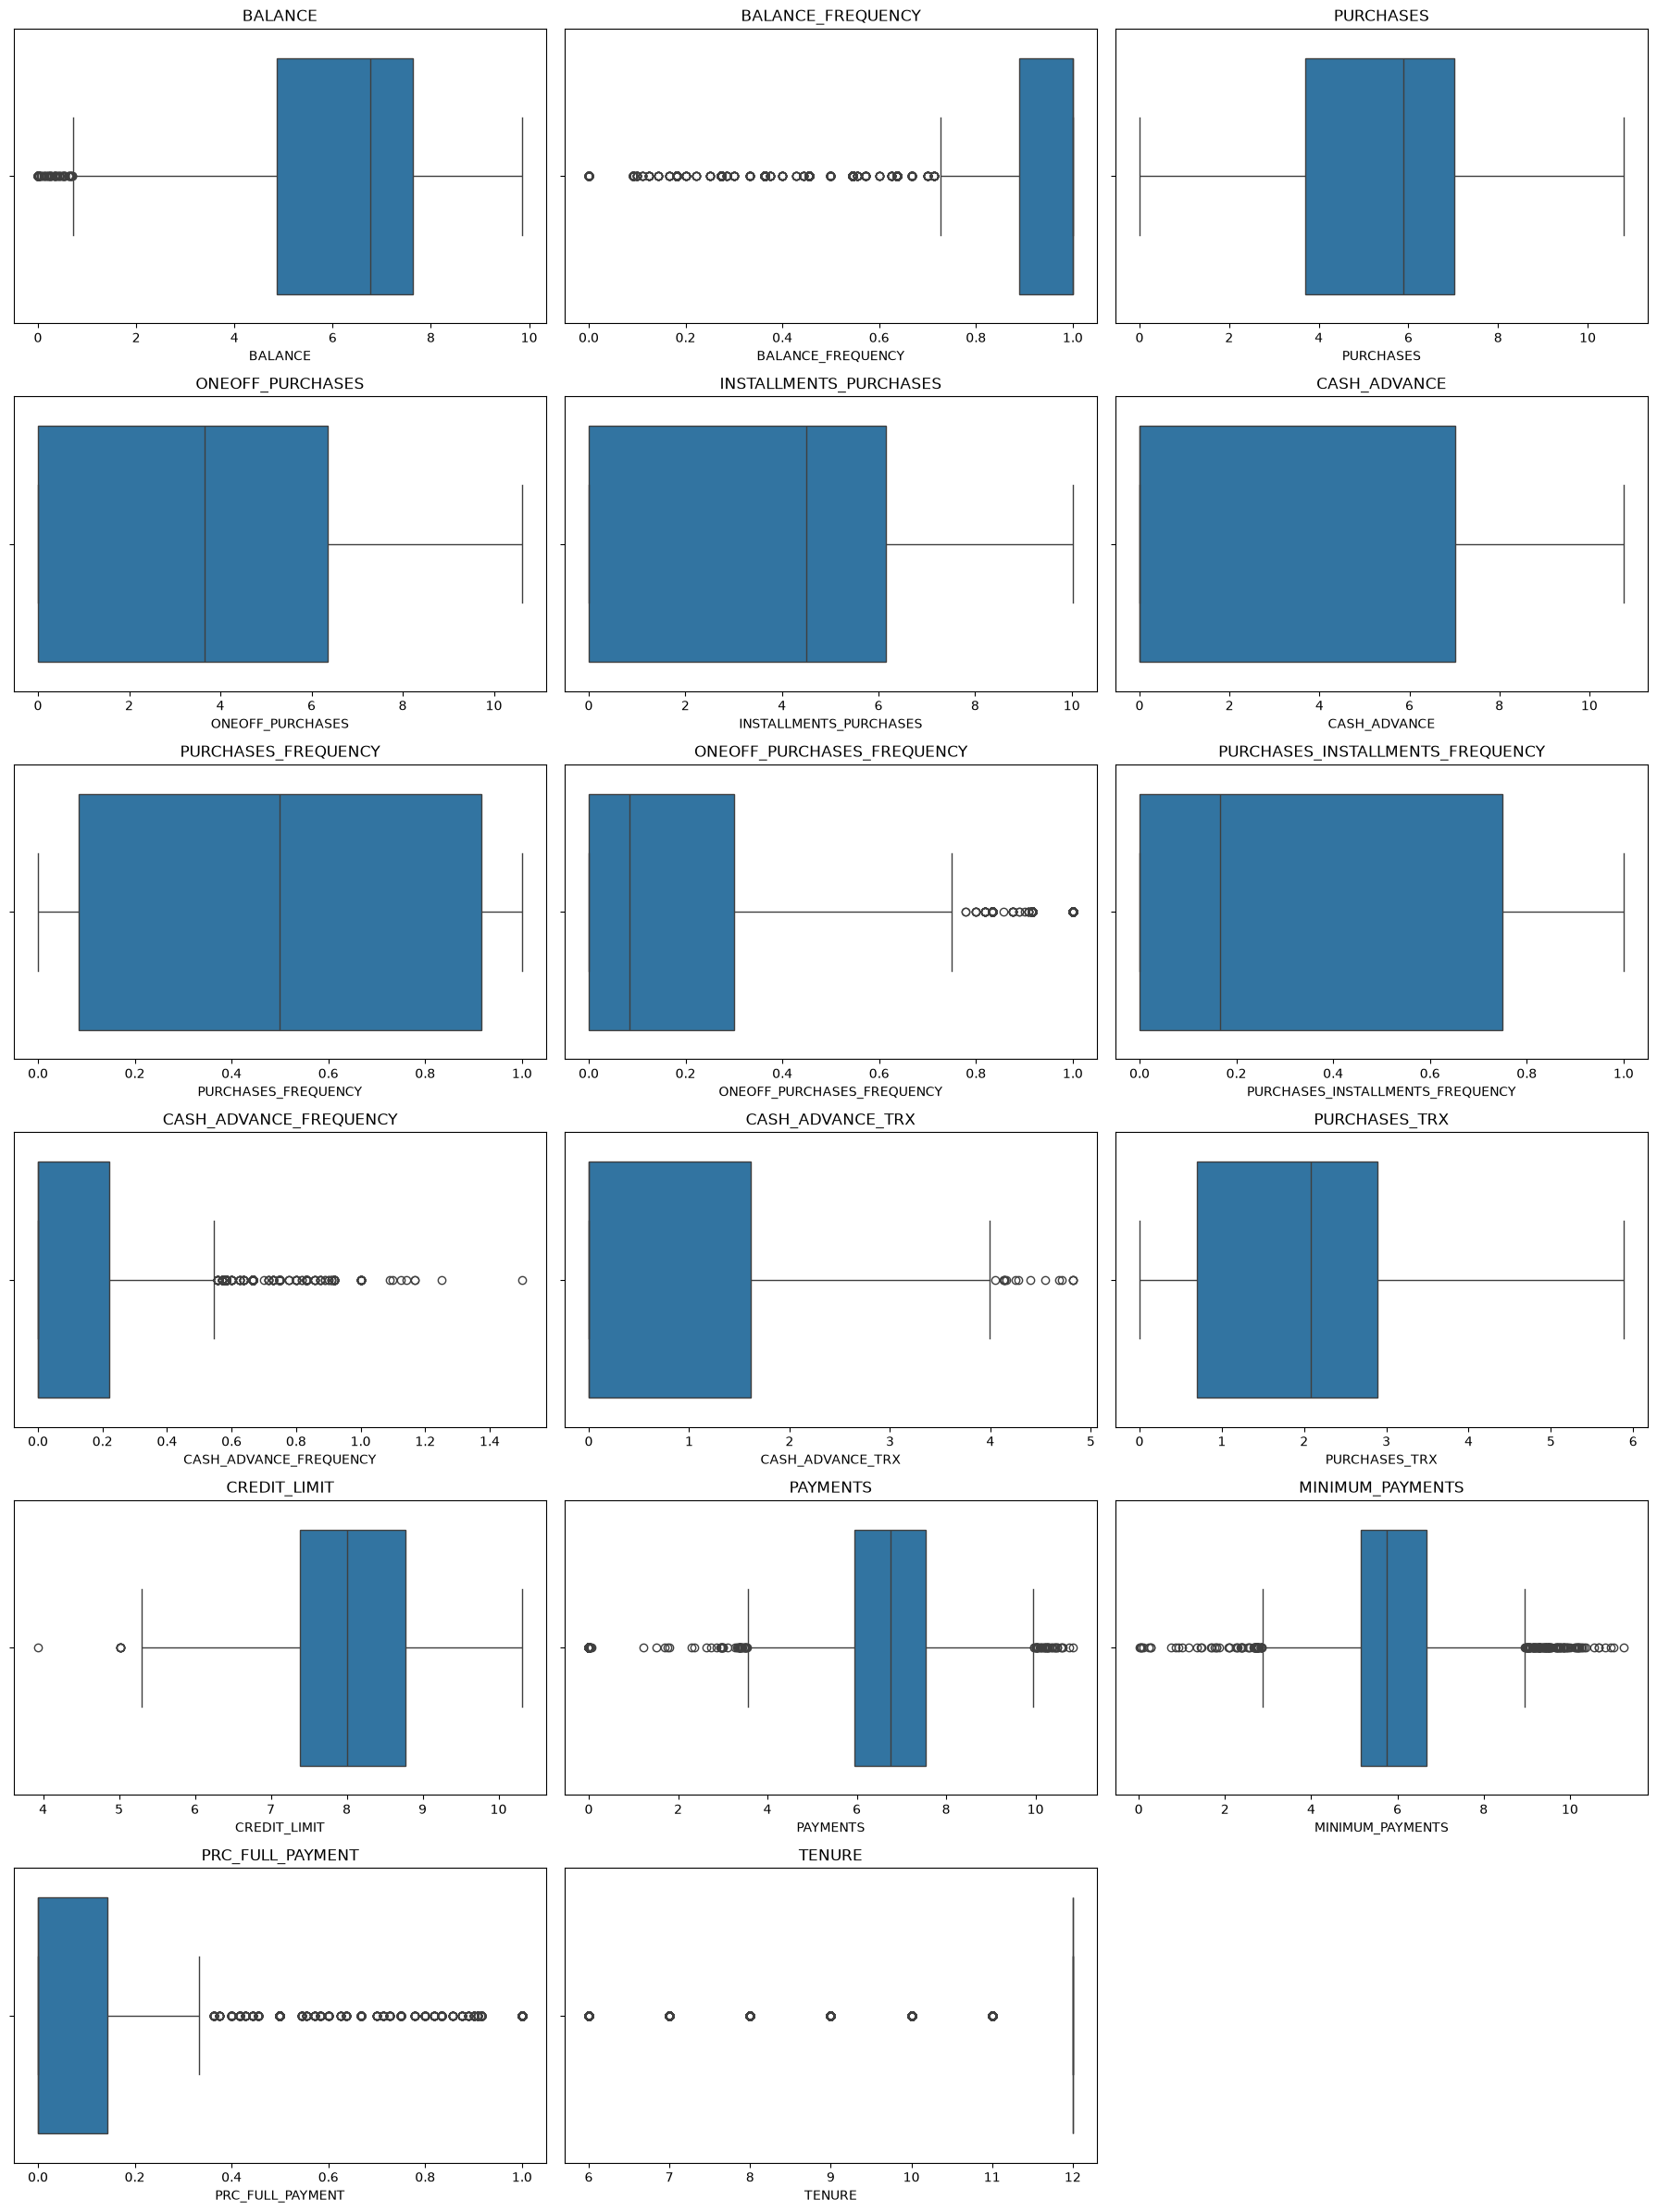

In [38]:
#Visualization after log transformation
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_log, x=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log.drop(columns=['CUST_ID']))

In [42]:
# 1. CUST_ID ko chhodkar bache huye numeric columns ki list lein
cols = df_log.drop(columns=['CUST_ID']).columns

# 2. NumPy array (X_scaled) ko DataFrame mein convert karein
df_scaled = pd.DataFrame(X_scaled, columns=cols)

# 3. View karein
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205218,-0.249434,-0.113532,-0.987090,0.394480,-0.930733,-0.806490,-0.678661,-0.707313,-0.675349,-0.810069,-0.579510,-1.447163,-0.824484,-0.829841,-0.525551,0.36068
1,0.948918,0.134325,-1.679855,-0.987090,-1.087454,1.528788,-1.221758,-0.678661,-0.916995,0.573963,0.784603,-1.379210,0.926060,1.065033,0.908184,0.234227,0.36068
2,0.824993,0.518084,0.600727,1.062022,-1.087454,-0.930733,1.269843,2.673451,-0.916995,-0.675349,-0.810069,0.487865,1.010229,-0.119300,0.450407,-0.525551,0.36068
3,0.624653,-1.016953,0.827499,1.265778,-1.087454,0.564372,-1.014125,-0.399319,-0.916995,-0.258913,-0.123281,-0.874655,1.010229,-4.161996,-0.144271,-0.525551,0.36068
4,0.271260,0.518084,-0.708481,-0.114307,-1.087454,-0.930733,-1.014125,-0.399319,-0.916995,-0.675349,-0.810069,-0.874655,-1.224909,-0.064979,-0.351833,-0.525551,0.36068


In [44]:
df_scaled.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,0.0,1.0,-3.06,-0.65,0.30,0.73,1.83
BALANCE_FREQUENCY,8950.0,0.0,1.0,-3.70,0.05,0.52,0.52,0.52
PURCHASES,8950.0,0.0,1.0,-1.68,-0.41,0.34,0.72,2.02
ONEOFF_PURCHASES,8950.0,0.0,1.0,-0.99,-0.99,0.14,0.97,2.28
INSTALLMENTS_PURCHASES,8950.0,0.0,1.0,-1.09,-1.09,0.37,0.91,2.16
CASH_ADVANCE,8950.0,0.0,1.0,-0.93,-0.93,-0.93,1.04,2.09
PURCHASES_FREQUENCY,8950.0,-0.0,1.0,-1.22,-1.01,0.02,1.06,1.27
ONEOFF_PURCHASES_FREQUENCY,8950.0,-0.0,1.0,-0.68,-0.68,-0.40,0.33,2.67
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.0,1.0,-0.92,-0.92,-0.50,0.97,1.60
CASH_ADVANCE_FREQUENCY,8950.0,0.0,1.0,-0.68,-0.68,-0.68,0.44,6.82


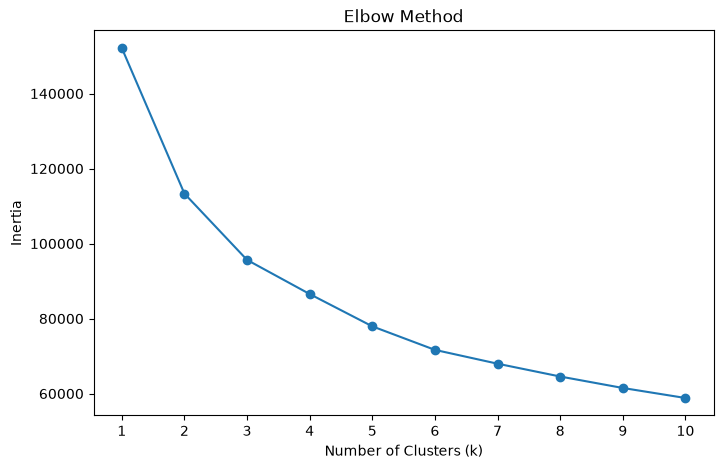

In [45]:
# Elbow method
inertia_list = []

k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia_list, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_range)
plt.show()

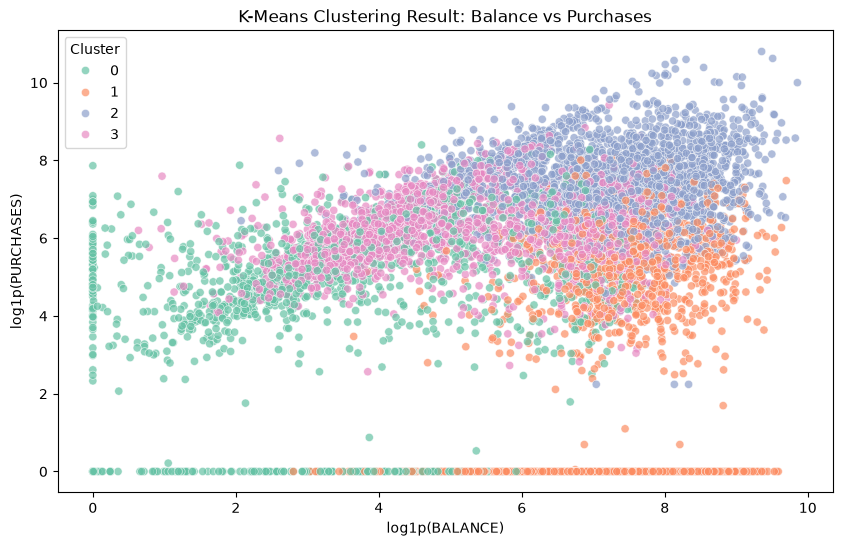

In [46]:
# kmeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)

labels = kmeans.labels_

# add cluster labels to the imputed df
df_clusters = df_imputed.copy()
df_clusters["cluster_kmeans"] = labels

# temporary df for visualization
df_kmeans_plot = df_log.copy()
df_kmeans_plot["cluster_kmeans"] = labels
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_kmeans_plot,
    x="BALANCE",
    y="PURCHASES",
    hue="cluster_kmeans",
    palette="Set2",
    alpha=0.7,
    s=35,
)

plt.title("K-Means Clustering Result: Balance vs Purchases")
plt.xlabel("log1p(BALANCE)")
plt.ylabel("log1p(PURCHASES)")
plt.legend(title="Cluster")
plt.show()

In [47]:
df_clusters["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    1570
1    2760
2    2580
3    2040
Name: count, dtype: int64

In [49]:
# 1. Feature columns extract karein
feature_cols = [
    col for col in df_clusters.columns 
    if col != "CUST_ID" and not col.startswith("cluster_")
]

# 2. StandardScaler se data scale karein aur naya DataFrame banayein
df_clusters_scaled = pd.DataFrame(
    scaler.fit_transform(df_clusters[feature_cols]), 
    columns=feature_cols
)

# 3. View karein
df_clusters_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


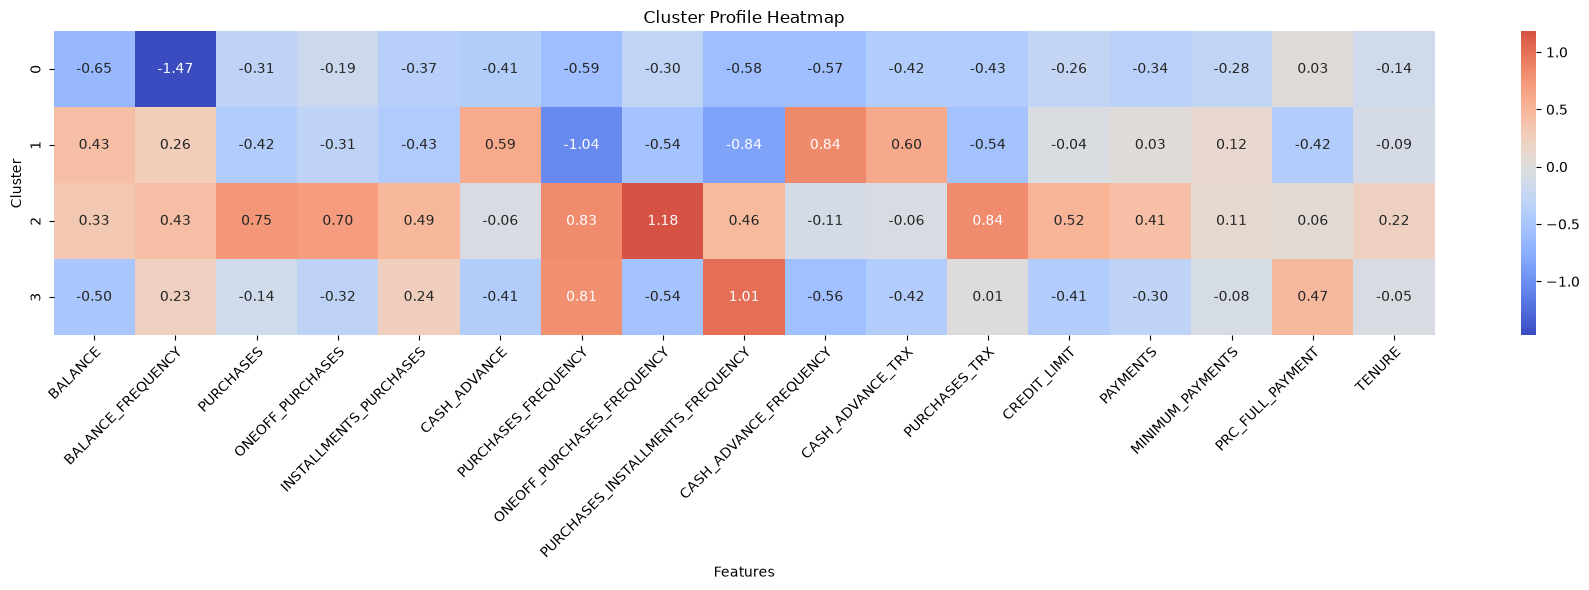

In [50]:
# temporary df for heatmap visualization
df_clusters_scaled_mean = df_clusters_scaled.copy()

# add cluster labels back to the scaled dataframe
df_clusters_scaled_mean["cluster_kmeans"] = df_clusters["cluster_kmeans"].values

# calculate mean values by cluster for heatmap visualization
df_clusters_scaled_mean = df_clusters_scaled_mean.groupby("cluster_kmeans")[
    feature_cols
].mean()

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    df_clusters_scaled_mean, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax
)

ax.set_title("Cluster Profile Heatmap")
ax.set_xlabel("Features")
ax.set_ylabel("Cluster")

ax.set_xticklabels(
    ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
)

plt.tight_layout()
plt.show()


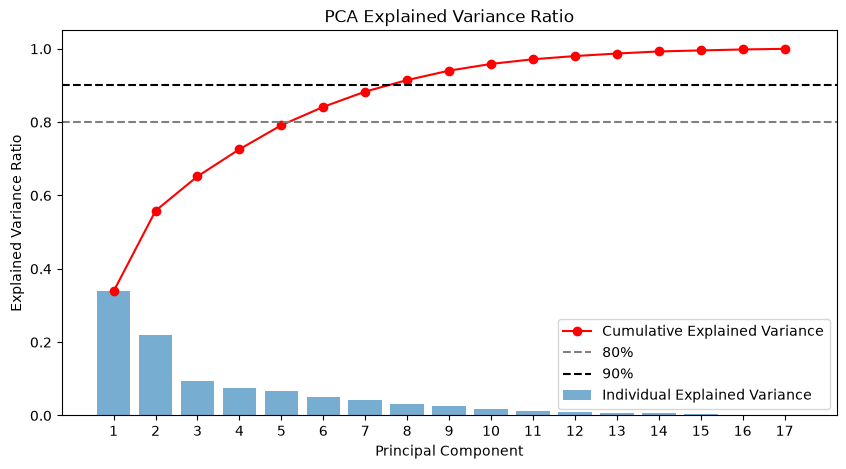

In [51]:
pca = PCA()
pca.fit(df_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
components = range(1, len(explained_variance_ratio) + 1)

plt.figure(figsize=(10, 5))

plt.bar(
    components,
    explained_variance_ratio,
    alpha=0.6,
    label="Individual Explained Variance",
)

plt.plot(
    components,
    cumulative_variance_ratio,
    marker="o",
    color="red",
    label="Cumulative Explained Variance",
)

plt.axhline(y=0.8, color="gray", linestyle="--", label="80%")
plt.axhline(y=0.9, color="black", linestyle="--", label="90%")

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance Ratio")
plt.xticks(components)
plt.legend()
plt.show()


In [53]:
# PCA + K-means
# make df for k-means
pca = PCA(n_components=5)
pca_clusters = pca.fit_transform(df_scaled)

pca_clusters_df = pd.DataFrame(
    pca_clusters,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5"],
    index=df_scaled.index,
)

In [54]:
pca_clusters_df.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], dtype='str')

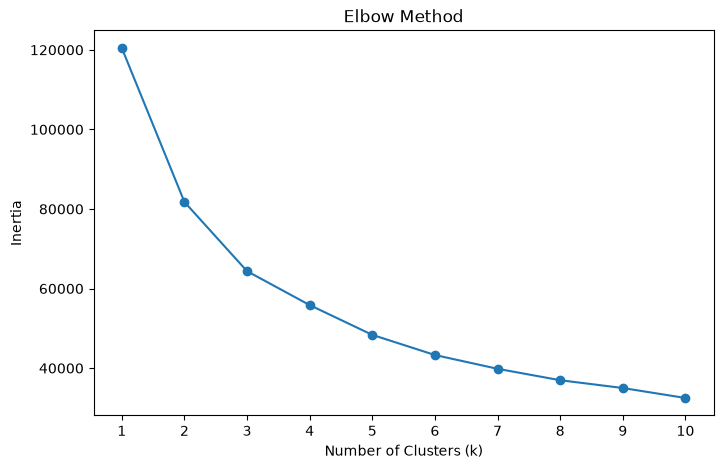

In [55]:
# elbow method
inertia_list = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_clusters_df)
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_list, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_range)
plt.show()


In [61]:
# PCA + K-means
pca_feature_cols = [
    "PC1",
    "PC2",
    "PC3",
    "PC4",
    "PC5",
]

pca_feature_df = pca_clusters_df[pca_feature_cols].copy()

kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
pca_labels = kmeans_pca.fit_predict(pca_feature_df)

pca_clusters_labeled_df = pca_feature_df.copy()
pca_clusters_labeled_df["cluster_kmeans_pca"] = pca_labels.astype(str)
fig = px.scatter_3d(
    pca_clusters_labeled_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster_kmeans_pca",
    opacity=0.65,
    title="PCA + K-Means Clustering Result (3D)",
)

fig.update_traces(marker=dict(size=3))

fig.update_layout(
    scene=dict(
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
        zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]:.1%})",
    ),legend_title_text="Cluster",
    width=900,
    height=700,
)

fig.show(renderer="notebook")


In [62]:
# add pca + cluster label to the original k-means df
df_clusters_pca = df_imputed.copy()
df_clusters_pca["cluster_kmeans_pca"] = pca_labels

In [64]:
# 1. StandardScaler se scale karke naya DataFrame banayein
df_clusters_pca_scaled = pd.DataFrame(
    scaler.fit_transform(df_clusters_pca[feature_cols]),
    columns=feature_cols
)

# 2. PCA Cluster labels add karein
df_clusters_pca_scaled["cluster_kmeans_pca"] = df_clusters_pca["cluster_kmeans_pca"].values

# 3. Cluster wise mean calculate karein
cluster_profile_pca_scaled = df_clusters_pca_scaled.groupby("cluster_kmeans_pca")[feature_cols].mean()

# Output view karein
cluster_profile_pca_scaled

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster_kmeans_pca,,,,,,,,,,,,,,,,,
0,-0.573388,-1.094207,-0.292477,-0.153927,-0.408585,-0.410194,-0.685217,-0.184139,-0.754875,-0.550015,-0.417348,-0.447336,-0.271174,-0.327780,-0.253588,-0.065133,-0.127621
1,0.348934,0.436354,0.774815,0.700216,0.545131,-0.044351,0.884413,1.158513,0.550247,-0.093551,-0.049805,0.882142,0.531309,0.435415,0.130410,0.060107,0.213905
2,0.454727,0.260669,-0.420451,-0.309231,-0.426077,0.623411,-1.032031,-0.539230,-0.836568,0.879275,0.636231,-0.541537,-0.012332,0.042900,0.125948,-0.421865,-0.083168
3,-0.552210,-0.001172,-0.160190,-0.321679,0.212704,-0.425102,0.799170,-0.551974,1.003176,-0.584770,-0.429410,-0.012492,-0.408271,-0.320010,-0.119298,0.519486,-0.049752


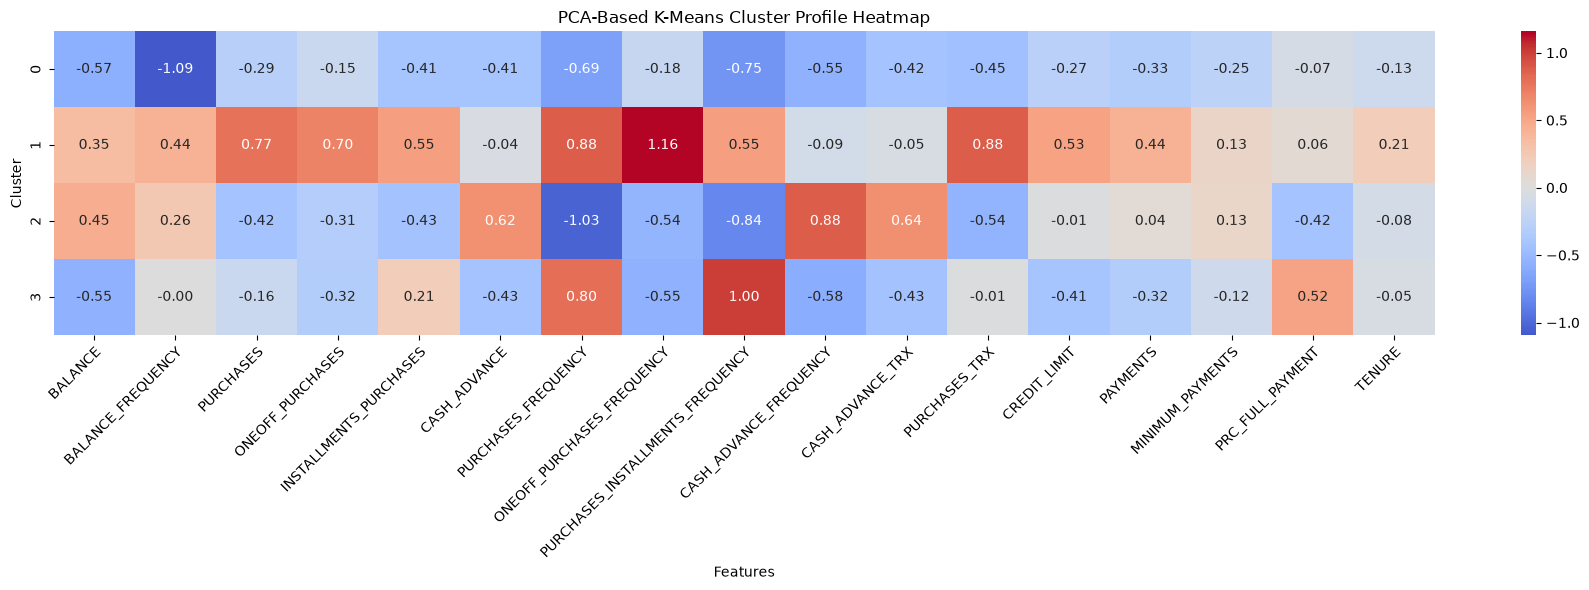

In [65]:
fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(
    cluster_profile_pca_scaled,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    ax=ax,
)

ax.set_title("PCA-Based K-Means Cluster Profile Heatmap")
ax.set_xlabel("Features")
ax.set_ylabel("Cluster")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)

plt.tight_layout()
plt.show()


In [66]:
df_clusters_pca["cluster_kmeans_pca"].value_counts().sort_index()

cluster_kmeans_pca
0    1642
1    2515
2    2692
3    2101
Name: count, dtype: int64

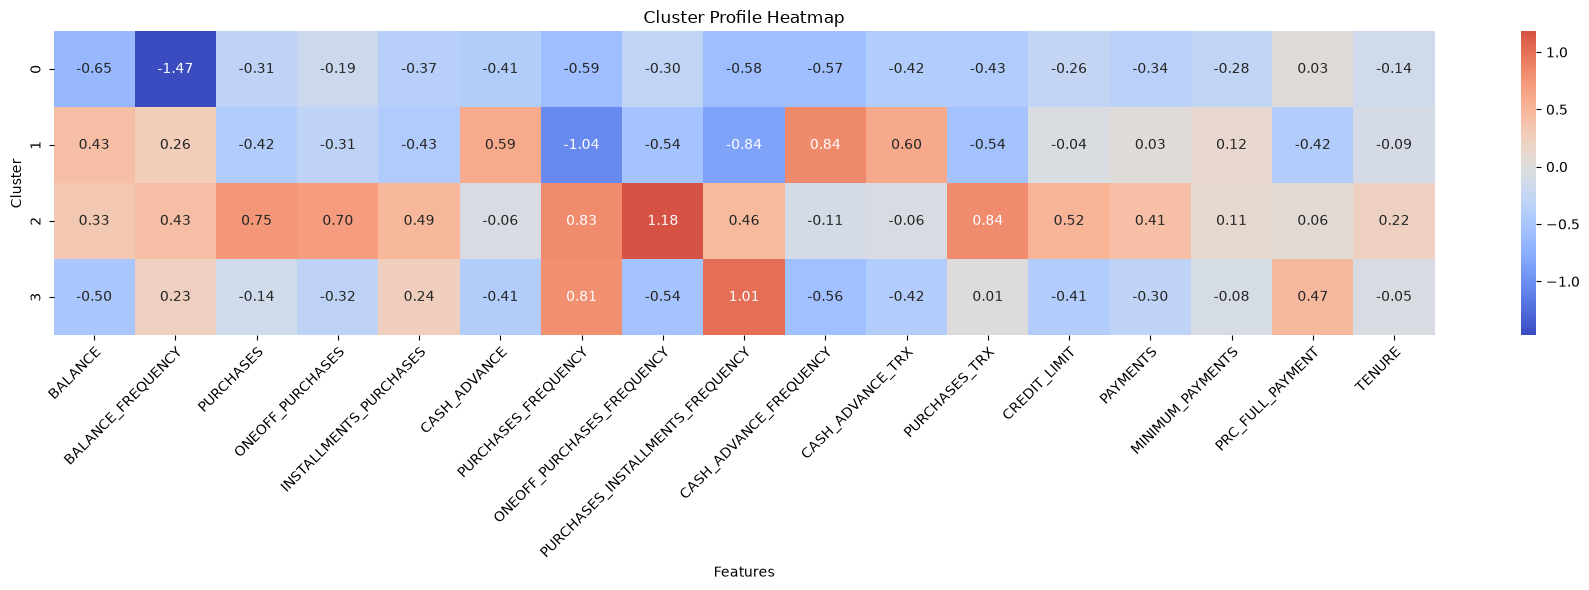

In [67]:
# original K-means for comparison
fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(
    df_clusters_scaled_mean, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax
)

ax.set_title("Cluster Profile Heatmap")
ax.set_xlabel("Features")
ax.set_ylabel("Cluster")

ax.set_xticklabels(
    ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
)

plt.tight_layout()
plt.show()

In [68]:
df_clusters["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    1570
1    2760
2    2580
3    2040
Name: count, dtype: int64